# 03 — Model Comparison

Compares Random Forest vs. XGBoost performance across all three endpoints,
using results from Module 6 (baseline training) and Module 7
(Bayesian hyperparameter optimisation).

Covers:
- CV and test-set metrics side by side, per model per endpoint
- Predicted vs. observed scatter plots on the held-out test set
- Residual analysis
- Hyperparameter search convergence (Optuna trial history)
- Best hyperparameters per endpoint

**Inputs:** `outputs/model_comparison.json`, `outputs/final_model_test_evaluation.json`,
`models/hyperparams.json`, `models/split_indices.json`,
`outputs/hyperparameter_search/*_trials.csv`

Run Modules 6–7 first if these files don't exist yet:
```bash
python src/module_06_training.py
python src/module_07_hyperopt.py
```

⚠️ This notebook reads test-set results that were computed **once** in
Module 7. Do not re-run test evaluation here — that would compromise the
pre-experimental validation design.

In [10]:
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, "../src")
from utils import load_config, load_json

PROJECT_ROOT = Path("..")
config = load_config(str(PROJECT_ROOT / "config" / "config.yaml"))

plt.style.use(config["FIGURES"].get("style", "seaborn-v0_8-whitegrid"))
sns.set_palette(config["FIGURES"].get("color_palette", "colorblind"))

ENDPOINTS = ["germination_percent", "root_length_mm", "shoot_length_mm"]

COMPARISON_PATH = PROJECT_ROOT / "outputs" / "model_comparison.json"
FINAL_EVAL_PATH = PROJECT_ROOT / "outputs" / "final_model_test_evaluation.json"
HYPERPARAMS_PATH = PROJECT_ROOT / "models" / "hyperparams.json"
SPLIT_PATH = PROJECT_ROOT / "models" / "split_indices.json"

assert COMPARISON_PATH.exists(), (
    f"'{COMPARISON_PATH}' not found. Run `python src/module_06_training.py` first."
)

model_comparison = load_json(str(COMPARISON_PATH))
print(f"Endpoints with results: {list(model_comparison.keys())}")

Endpoints with results: ['germination_percent', 'root_length_mm', 'shoot_length_mm']


## 1. Baseline model comparison (Module 6)

Cross-validated RMSE/R² and held-out test metrics for both candidate models, before hyperparameter tuning.

In [11]:
rows = []
for ep, ep_results in model_comparison.items():
    for model_name in ["random_forest", "xgboost"]:
        if model_name not in ep_results:
            continue
        m = ep_results[model_name]
        rows.append({
            "endpoint": ep,
            "model": model_name,
            "cv_rmse_mean": m["cv_rmse_mean"],
            "cv_rmse_std": m["cv_rmse_std"],
            "cv_r2_mean": m["cv_r2_mean"],
            "test_r2": m["r2"],
            "test_rmse": m["rmse"],
            "test_mae": m["mae"],
            "selected": ep_results.get("selected_model") == model_name,
        })

baseline_df = pd.DataFrame(rows)
baseline_df

,endpoint,model,cv_rmse_mean,cv_rmse_std,cv_r2_mean,test_r2,test_rmse,test_mae,selected
0,germination_percent,random_forest,13.702664,4.365952,0.659489,0.555792,14.903655,9.381849,True
1,germination_percent,xgboost,14.525010,4.162706,0.618349,0.569996,14.663445,9.394276,False
2,root_length_mm,random_forest,13.269084,7.841478,0.694237,0.759686,10.935981,6.570896,True
3,root_length_mm,xgboost,14.397163,7.275860,0.647365,0.691317,12.394393,7.078600,False
4,shoot_length_mm,random_forest,19.939659,15.335686,0.647657,0.747595,13.695528,8.333218,True
5,shoot_length_mm,xgboost,21.719872,14.988095,0.592421,0.675210,15.535710,10.172639,False


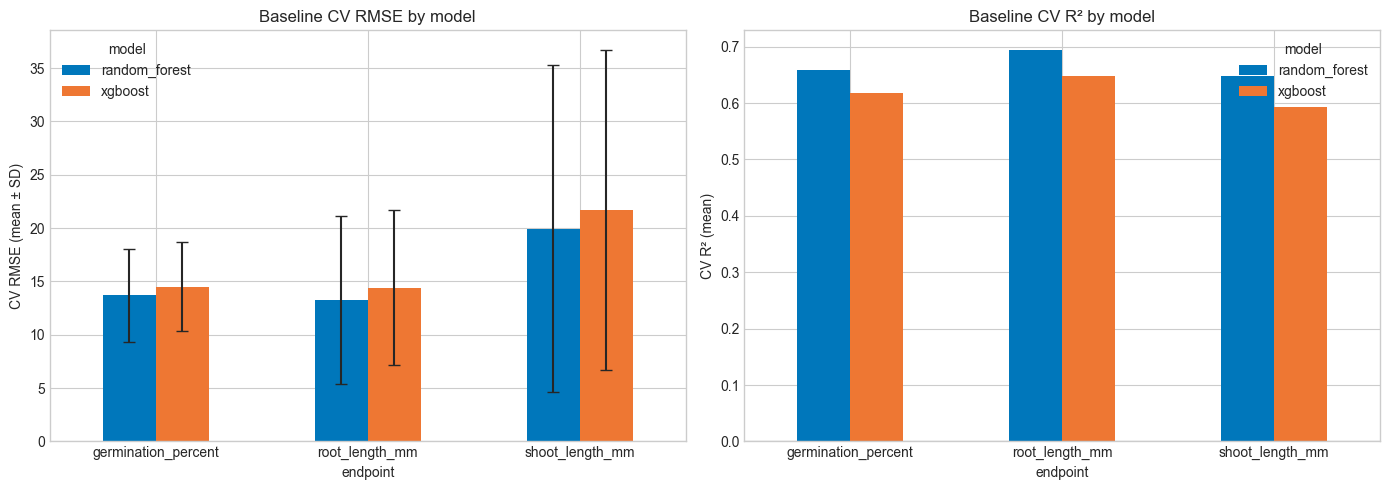

Selected model per endpoint (Module 6, pre-tuning):
  germination_percent: random_forest
  root_length_mm: random_forest
  shoot_length_mm: random_forest


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pivot_rmse = baseline_df.pivot(index="endpoint", columns="model", values="cv_rmse_mean")
pivot_rmse.plot(kind="bar", ax=axes[0], yerr=baseline_df.pivot(index="endpoint", columns="model", values="cv_rmse_std"),
                 capsize=4, color=["#0077BB", "#EE7733"])
axes[0].set_ylabel("CV RMSE (mean ± SD)")
axes[0].set_title("Baseline CV RMSE by model")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

pivot_r2 = baseline_df.pivot(index="endpoint", columns="model", values="cv_r2_mean")
pivot_r2.plot(kind="bar", ax=axes[1], color=["#0077BB", "#EE7733"])
axes[1].set_ylabel("CV R² (mean)")
axes[1].set_title("Baseline CV R² by model")
axes[1].axhline(0, color="grey", linewidth=0.8)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

print("Selected model per endpoint (Module 6, pre-tuning):")
for ep, ep_results in model_comparison.items():
    print(f"  {ep}: {ep_results.get('selected_model')}")

## 2. Hyperparameter search convergence (Module 7)

Each point is one Optuna trial; lower is better (objective = CV RMSE).

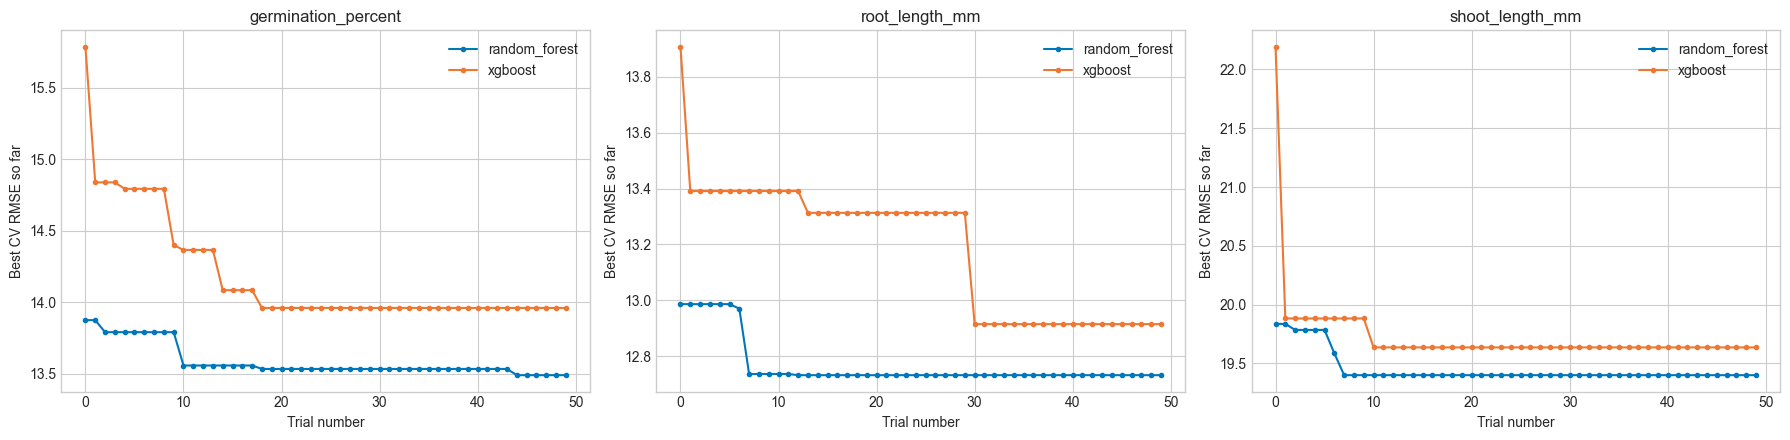

In [13]:
search_dir = PROJECT_ROOT / "outputs" / "hyperparameter_search"
trial_files = sorted(search_dir.glob("*_trials.csv")) if search_dir.exists() else []

if trial_files:
    fig, axes = plt.subplots(1, len(ENDPOINTS), figsize=(6 * len(ENDPOINTS), 4.5), squeeze=False)
    for ax, ep in zip(axes[0], ENDPOINTS):
        for model_name, color in [("random_forest", "#0077BB"), ("xgboost", "#EE7733")]:
            f = search_dir / f"{model_name}_{ep}_trials.csv"
            if f.exists():
                trials = pd.read_csv(f)
                running_best = trials["value"].cummin()
                ax.plot(trials["number"], running_best, label=model_name, color=color, marker="o", markersize=3)
        ax.set_xlabel("Trial number")
        ax.set_ylabel("Best CV RMSE so far")
        ax.set_title(ep)
        ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No hyperparameter search trial files found. Run Module 7 first.")

## 3. Best hyperparameters per endpoint

In [14]:
if HYPERPARAMS_PATH.exists():
    hyperparams = load_json(str(HYPERPARAMS_PATH))
    for ep, ep_results in hyperparams.items():
        print(f"\n=== {ep} ===")
        print(f"Selected: {ep_results.get('selected_model')}")
        for model_name in ["random_forest", "xgboost"]:
            if model_name in ep_results:
                print(f"\n  {model_name} (best CV RMSE = {ep_results[model_name]['best_cv_rmse']:.4f}):")
                for k, v in ep_results[model_name]["best_params"].items():
                    print(f"    {k}: {v}")
else:
    print("No hyperparams.json found. Run Module 7 first.")


=== germination_percent ===
Selected: random_forest

  random_forest (best CV RMSE = 13.4898):
    n_estimators: 200
    max_depth: 3
    min_samples_split: 2
    min_samples_leaf: 4
    max_features: sqrt
    bootstrap: False

  xgboost (best CV RMSE = 13.9600):
    n_estimators: 50
    max_depth: 3
    learning_rate: 0.05
    subsample: 1.0
    colsample_bytree: 1.0
    reg_alpha: 0
    reg_lambda: 0.1
    min_child_weight: 1

=== root_length_mm ===
Selected: random_forest

  random_forest (best CV RMSE = 12.7318):
    n_estimators: 200
    max_depth: None
    min_samples_split: 2
    min_samples_leaf: 4
    max_features: sqrt
    bootstrap: True

  xgboost (best CV RMSE = 12.9145):
    n_estimators: 500
    max_depth: 3
    learning_rate: 0.01
    subsample: 0.6
    colsample_bytree: 1.0
    reg_alpha: 1.0
    reg_lambda: 10.0
    min_child_weight: 1

=== shoot_length_mm ===
Selected: random_forest

  random_forest (best CV RMSE = 19.4000):
    n_estimators: 200
    max_depth: 10
 

## 4. Final test-set evaluation

These numbers come from `outputs/final_model_test_evaluation.json`, computed
**exactly once** in Module 7 on the held-out test split. This is the
authoritative pre-experimental performance estimate.

In [15]:
if FINAL_EVAL_PATH.exists():
    final_eval = load_json(str(FINAL_EVAL_PATH))
    final_df = pd.DataFrame(final_eval).T
    final_df.index.name = "endpoint"
    final_df
else:
    print("No final_model_test_evaluation.json found. Run Module 7 first.")
    final_df = pd.DataFrame()
final_df

,r2,rmse,mae,model_type
endpoint,,,,
germination_percent,0.53337,15.275165,9.744478,random_forest
root_length_mm,0.741325,11.346084,6.755232,random_forest
shoot_length_mm,0.738615,13.937038,8.481261,random_forest


## 5. Predicted vs. observed on the held-out test set

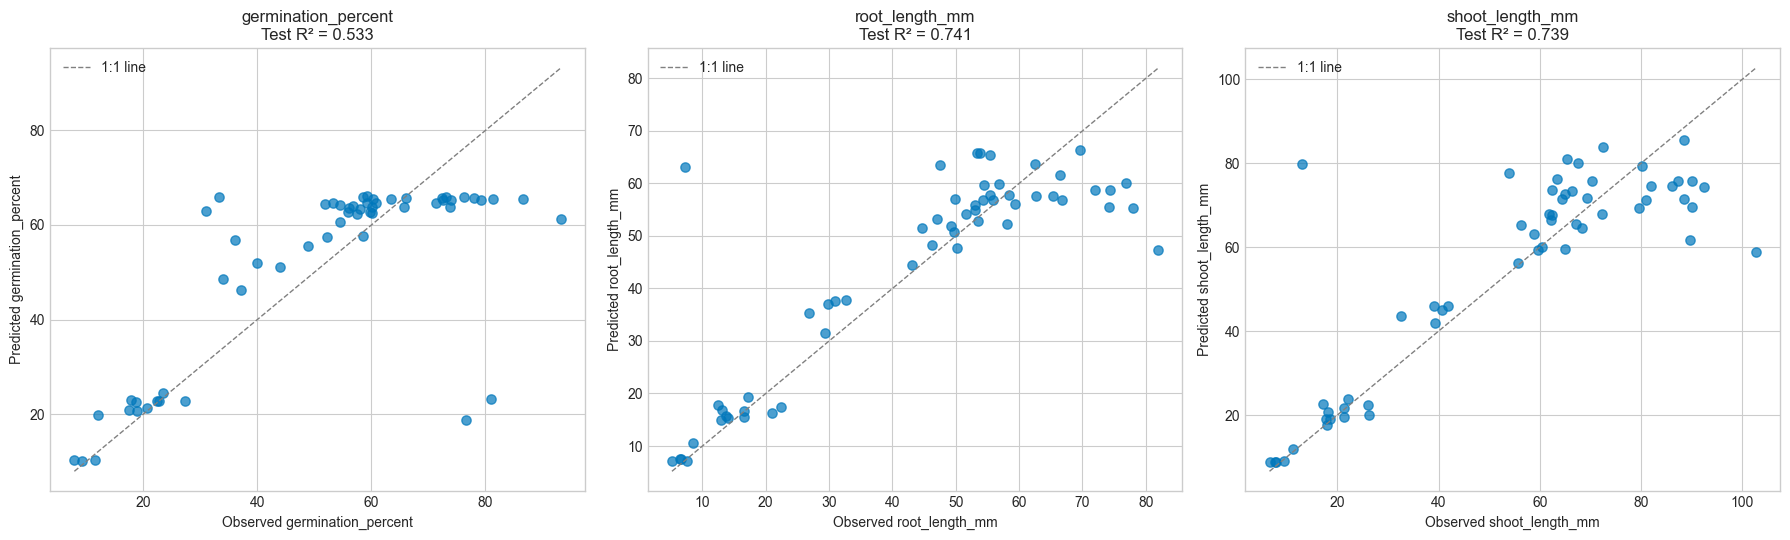

In [16]:
split_indices = load_json(str(SPLIT_PATH)) if SPLIT_PATH.exists() else {}
feat_df = pd.read_csv(PROJECT_ROOT / "data" / "features" / "osmotic_corrected_matrix.csv")
full_df = pd.read_csv(PROJECT_ROOT / "data" / "features" / "full_matrix_with_targets.csv")
feature_names = load_json(str(PROJECT_ROOT / "data" / "features" / "feature_names.json"))
feature_names = [f for f in feature_names if f in feat_df.columns]

fig, axes = plt.subplots(1, len(ENDPOINTS), figsize=(6 * len(ENDPOINTS), 5.5), squeeze=False)

for ax, ep in zip(axes[0], ENDPOINTS):
    model_path = PROJECT_ROOT / "models" / f"best_model_{ep}.pkl"
    if not model_path.exists() or ep not in split_indices:
        ax.set_title(f"{ep} (model not found)")
        continue

    model = joblib.load(model_path)
    y = full_df[ep].dropna()
    
    model_features = list(model.feature_names_in_)
    X = feat_df.loc[y.index][model_features]

    test_idx = [i for i in split_indices[ep]["test_indices"] if i in X.index]
    X_test = X.loc[test_idx]
    y_test = y.loc[test_idx]
    
    y_pred = model.predict(X_test)

    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, "--", color="grey", linewidth=1, label="1:1 line")
    ax.scatter(y_test, y_pred, alpha=0.7, s=45, color="#0077BB")
    ax.set_xlabel(f"Observed {ep}")
    ax.set_ylabel(f"Predicted {ep}")
    r2 = final_eval[ep]["r2"] if FINAL_EVAL_PATH.exists() and ep in final_eval else np.nan
    ax.set_title(f"{ep}\nTest R² = {r2:.3f}" if not np.isnan(r2) else ep)
    ax.legend()

plt.tight_layout()
plt.show()

## 6. Residual analysis

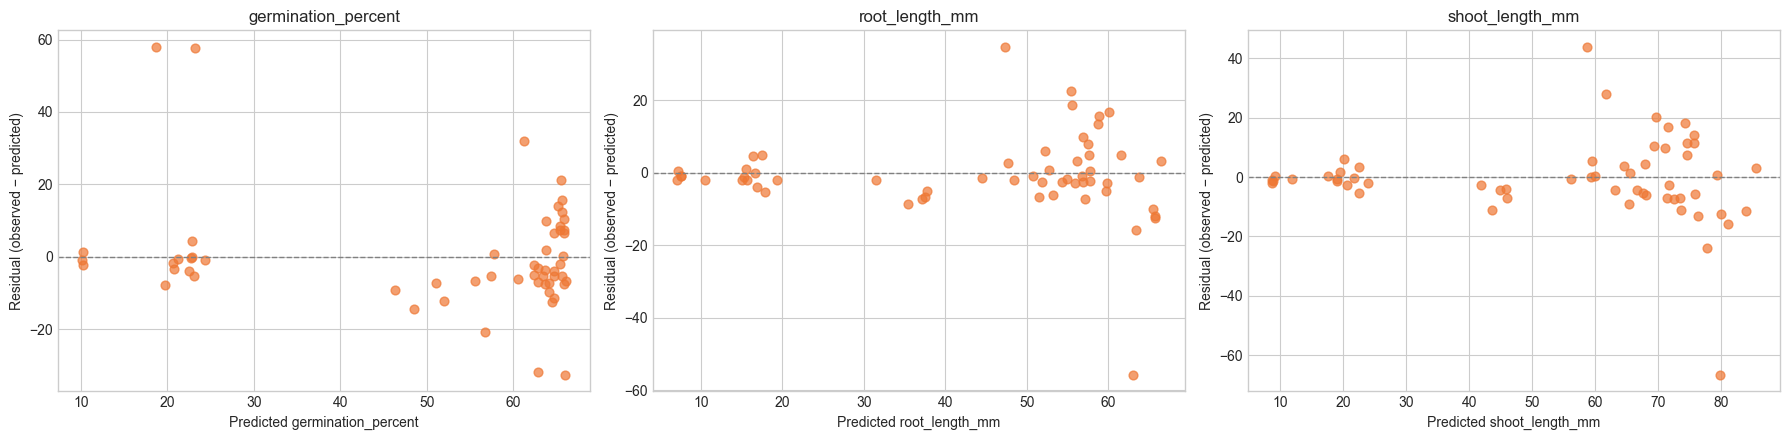

In [17]:
fig, axes = plt.subplots(1, len(ENDPOINTS), figsize=(6 * len(ENDPOINTS), 4.5), squeeze=False)

for ax, ep in zip(axes[0], ENDPOINTS):
    model_path = PROJECT_ROOT / "models" / f"best_model_{ep}.pkl"
    if not model_path.exists() or ep not in split_indices:
        continue

    model = joblib.load(model_path)
    y = full_df[ep].dropna()
    
    # FIX: Extract columns using the model's fitted features instead of the old array
    model_features = list(model.feature_names_in_)
    X = feat_df.loc[y.index][model_features]
    
    test_idx = [i for i in split_indices[ep]["test_indices"] if i in X.index]
    X_test = X.loc[test_idx]
    y_test = y.loc[test_idx]
    y_pred = model.predict(X_test)
    residuals = y_test.values - y_pred

    ax.scatter(y_pred, residuals, alpha=0.7, s=40, color="#EE7733")
    ax.axhline(0, color="grey", linestyle="--", linewidth=1)
    ax.set_xlabel(f"Predicted {ep}")
    ax.set_ylabel("Residual (observed − predicted)")
    ax.set_title(ep)

plt.tight_layout()
plt.show()

## 7. Notes for next stage

Things worth checking before moving to SHAP analysis:

- If CV RMSE std is large relative to the mean for any endpoint, the
  dataset may be too small or heterogeneous for stable estimates
- Compare the selected model in Module 6 (pre-tuning) against Module 7
  (post-tuning) — tuning occasionally flips the winner
- Look for systematic residual patterns (e.g., consistent under-prediction
  at high concentration), which would suggest a missing feature or
  non-linearity the model isn't capturing

Proceed to `04_shap_analysis.ipynb` to interpret what's driving these
predictions.